# ADALINE desde cero: de la formulación matemática a una arquitectura computacional

## Parcial en casa — componente práctico

En el ejercicio anterior trabajamos con el perceptrón de Rosenblatt. Allí la arquitectura funcional fue construida conjuntamente y el trabajo consistió en completar las funciones que la componían.

En este ejercicio cambia deliberadamente el nivel de autonomía:

> **usted recibe el problema, la formulación matemática, una función fundamental ya implementada, datos, experimentos y criterios de integración; la arquitectura de software debe diseñarla usted.**

No existe una única arquitectura correcta. Dos soluciones pueden ser diferentes y ambas ser válidas si:

- las responsabilidades están bien separadas;
- los contratos de entrada y salida son claros;
- la implementación reproduce correctamente el algoritmo;
- las funciones se conectan de manera coherente;
- las pruebas permiten verificar el comportamiento esperado.

El cuaderno es **autocontenido**: no necesita un PDF externo ni archivos de datos adicionales.

### Qué debe entregar dentro de este mismo notebook

1. propuesta de arquitectura funcional;
2. diagrama de conexión entre funciones;
3. derivación de la regla de actualización;
4. implementación de ADALINE con NumPy;
5. validaciones con `raise ValueError`;
6. `type hints` y docstrings;
7. pruebas diseñadas por usted;
8. entrenamiento y seguimiento de la pérdida;
9. experimentos con el `learning rate`;
10. comparación entre variables en escalas distintas y variables estandarizadas;
11. evaluación sobre train, validation y test;
12. comparación conceptual entre perceptrón y ADALINE;
13. reflexión final sobre sus decisiones de arquitectura.

### Restricciones

- El núcleo de ADALINE debe implementarse con **NumPy**.
- No utilice una implementación equivalente de `scikit-learn`, TensorFlow, PyTorch u otra biblioteca.
- No utilice clases. La solución debe permanecer en una arquitectura funcional.
- Puede crear tantas funciones auxiliares como considere necesarias.
- Debe utilizar la función `actualizar_pesos_adaline` proporcionada.
- Para que las celdas posteriores puedan ejecutar arquitecturas diferentes, deberá respetar únicamente dos **interfaces públicas**:
  - `entrenar_adaline(...)`
  - `predecir_adaline(...)`

Estas dos firmas no determinan la arquitectura interna.

### Dependencias

En el ambiente del curso deben estar disponibles:

```bash
uv add numpy pandas matplotlib
```

El ambiente virtual no debe subirse al repositorio.

# 1. ¿Qué cambia respecto al perceptrón?

Ambos modelos parten de:

\[
z_i=\mathbf w^\top \tilde{\mathbf x}_i.
\]

La diferencia está en **cómo utilizan esa cantidad para aprender**.

### Perceptrón

\[
y_i z_i\le 0
\quad\Longrightarrow\quad
\mathbf w\leftarrow\mathbf w+\eta y_i\tilde{\mathbf x}_i.
\]

La pregunta esencial es:

> ¿la observación quedó bien o mal clasificada?

### ADALINE

Durante el entrenamiento ADALINE utiliza directamente la salida lineal:

\[
a_i=z_i=\mathbf w^\top\tilde{\mathbf x}_i,
\]

y define un error continuo:

\[
e_i=y_i-a_i.
\]

Por tanto, la magnitud del error sí participa en el aprendizaje.

En este ejercicio:

\[
y_i\in\{-1,+1\}.
\]

La función signo aparecerá **solo para convertir la salida lineal en una clase durante inferencia**.

# 2. La función que queremos minimizar

Trabajaremos con:

\[
\boxed{
L(\mathbf w)=
\frac{1}{2n}
\sum_{i=1}^{n}
\left(
y_i-\mathbf w^\top\tilde{\mathbf x}_i
\right)^2
}
\]

o, matricialmente,

\[
L(\mathbf w)
=
\frac{1}{2n}
\left\|
\mathbf y-\tilde X\mathbf w
\right\|_2^2.
\]

Antes de programar, responda:

1. ¿por qué el cuadrado evita que errores positivos y negativos se cancelen?;
2. ¿qué efecto tiene sobre errores de distinta magnitud?;
3. ¿por qué el factor \(1/2\) es conveniente?;
4. ¿qué variable estamos optimizando?

**Respuesta:**

> 1. Porque si sumara los errores tal cual (sin elevar al cuadrado), uno positivo y uno negativo se anulan entre sí, lo que esconde el hecho de que el modelo se equivocó en ambos casos. Al elevar al cuadrado, no importa si el error fue +3 o -3: ambos aportan positivo a la suma, así que no hay forma de ignorar errores compensándose unos con otros.
> 2. Los errores grandes pesan mucho más que los pequeños. No es que un error de 4 pese el doble que uno de 2, pesa cuatro veces más (4^2 vs 2^2). Eso hace que el modelo se enfoque en corregir primero donde más se está equivocando, no en repartir el ajuste parejo entre todo
> 3. El 1/2 es un truco de conveniencia matemática: al derivar el término que está al cuadrado sale un 2 por la regla de la cadena, y ese 2 se cancela justo con el 1/2 que puse antes. Así el gradiente me queda limpio, sin arrastrar constantes extra que no aportan nada.
> 4. Lo que estoy optimizando es w. Los datos (X,y) están fijos, no cambian; lo único que se mueve durante el entrenamiento es el vector de pesos.

## 2.1 Derivación guiada

Defina:

\[
\mathbf e=\mathbf y-\tilde X\mathbf w.
\]

Entonces:

\[
L(\mathbf w)
=
\frac{1}{2n}\mathbf e^\top\mathbf e.
\]

Complete la derivación hasta obtener:

\[
\nabla_{\mathbf w}L
=
\boxed{\qquad\qquad\qquad\qquad}
\]

Luego use:

\[
\mathbf w_{\text{nuevo}}
=
\mathbf w-\eta\nabla_{\mathbf w}L
\]

para escribir la regla de actualización:

\[
\boxed{
\mathbf w_{\text{nuevo}}
=
\qquad\qquad\qquad\qquad
}
\]

<details>
<summary><strong>Pista 1 — dimensiones</strong></summary>

Si

\[
\tilde X\in\mathbb R^{n\times(d+1)}
\quad\text{y}\quad
\mathbf e\in\mathbb R^n,
\]

entonces el gradiente debe pertenecer a \(\mathbb R^{d+1}\), igual que \(\mathbf w\).

</details>

<details>
<summary><strong>Pista 2 — estructura del gradiente</strong></summary>

La expresión debe contener \(\tilde X^\top\mathbf e\). Piense además en el signo y en el factor \(1/n\).

</details>

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

np.set_printoptions(precision=5, suppress=True)

# 3. Datos autocontenidos

El cuaderno genera los datos internamente.

Usaremos un conjunto sintético binario de dos características. Más adelante construiremos una versión equivalente en la que una característica tenga una escala mucho mayor.

Las funciones de generación, partición y estandarización **ya están implementadas** y no forman parte de la arquitectura de ADALINE.

In [ ]:
def crear_datos_sinteticos(
    n: int = 600,
    semilla: int = 2026,
) -> tuple[np.ndarray, np.ndarray]:
    """Genera un problema binario bidimensional."""
    # n debe ser suficientemente grande para que el experimento tenga sentido
    if n < 40:
        raise ValueError("n debe ser al menos 40.")
    # n debe ser par para poder repartir exactamente la mitad a cada clase
    if n % 2 != 0:
        raise ValueError("n debe ser par.")

    # semilla fija, mismos datos cada vez que se ejecute
    rng = np.random.default_rng(semilla)
    mitad = n // 2  # observaciones por clase

    # clase negativa (-1): nube gaussiana centrada en (-1.5, -1.0)
    clase_negativa = rng.normal(
        loc=(-1.5, -1.0),   # centro de la nube en (x1, x2)
        scale=(0.70, 0.60), # desviación estándar en cada eje
        size=(mitad, 2),    # cuantos puntos y cuantas dimensiones
    )

    # clase positiva (+1): nube gaussiana centrada en (1.5, 1.0)
    clase_positiva = rng.normal(
        loc=(1.5, 1.0),
        scale=(0.70, 0.60),
        size=(mitad, 2),
    )

    # apilamos verticalmente ambas nubes en una sola matriz
    X = np.vstack((clase_negativa, clase_positiva))

    # -1 para toda la primera mitad, +1 para la segunda
    y = np.concatenate(
        (-np.ones(mitad, dtype=int), np.ones(mitad, dtype=int))
    )

    # se mezcla el orden para que las clases no queden agrupadas
    idx = rng.permutation(n)
    return X[idx], y[idx]

def particion_estratificada(
    X: np.ndarray,
    y: np.ndarray,
    proporcion_train: float = 0.70,
    proporcion_val: float = 0.15,
    semilla: int = 2026,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Divide train/validation/test manteniendo el balance."""
    # proporcion_train debe estar estrictamente entre 0 y 1
    if not 0 < proporcion_train < 1:
        raise ValueError("proporcion_train debe pertenecer a (0, 1).")
    # lo mismo para proporcion_val
    if not 0 < proporcion_val < 1:
        raise ValueError("proporcion_val debe pertenecer a (0, 1).")
    # si train + val ya cubre el 100% (o más), no queda nada para test
    if proporcion_train + proporcion_val >= 1:
        raise ValueError("Debe quedar una proporción positiva para test.")

    rng = np.random.default_rng(semilla)
    train_idx, val_idx, test_idx = [], [], []

    # Por cada clase, repartimos por separado en la misma proporción (estratificada)
    for etiqueta in np.unique(y):
        idx = rng.permutation(np.flatnonzero(y == etiqueta))  # índices de esta clase, barajados
        n_clase = len(idx)
        n_train = round(proporcion_train * n_clase)  # cuántos van a train
        n_val = round(proporcion_val * n_clase)       # cuántos van a validation

        train_idx.extend(idx[:n_train])                    # los primeros n_train
        val_idx.extend(idx[n_train:n_train + n_val])        # los siguientes n_val
        test_idx.extend(idx[n_train + n_val:])              # el resto

    # Volvemos a mezclar cada conjunto completo, para mezclar las clases entre sí
    train_idx = rng.permutation(train_idx)
    val_idx = rng.permutation(val_idx)
    test_idx = rng.permutation(test_idx)

    return (
        X[train_idx], y[train_idx],
        X[val_idx], y[val_idx],
        X[test_idx], y[test_idx],
    )

def estandarizar_desde_train(
    X_train: np.ndarray,
    X_val: np.ndarray,
    X_test: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Estandariza usando únicamente media y desviación de train."""
    # Media y desviación se calculan solo con train, sino habría data leakage
    media = X_train.mean(axis=0)
    desviacion = X_train.std(axis=0)

    # Si alguna característica es constante en train (desviación 0), dividir entre ella daría división por cero, se rechaza explícitamente
    if np.any(np.isclose(desviacion, 0.0)):
        raise ValueError("No se puede estandarizar una característica constante.")

    # Aplicamos la misma transformación a los tres conjuntos: z = (x - media) / desviación
    return (
        (X_train - media) / desviacion,
        (X_val - media) / desviacion,
        (X_test - media) / desviacion,
        media,
        desviacion,
    )


# 4. EDA antes de entrenar

Verifique forma, tipos, valores faltantes, balance de clases y geometría aproximada.

In [3]:
X, y = crear_datos_sinteticos()   # generamos el conjunto sintético (n=600 por defecto)

datos = pd.DataFrame(
    {
        "x1": X[:, 0],  # primera columna de X, variable x1
        "x2": X[:, 1],  # segunda columna de X, variable x2
        "y": y,         # etiqueta de cada observación
    }
)

datos.head()

,x1,x2,y
0,0.504078,1.376973,1
1,2.415865,0.059543,1
2,-0.916254,-0.317370,-1
3,1.971840,1.278964,1
4,-2.011872,-0.839371,-1


In [4]:
print("Forma:", datos.shape)  # (n_observaciones, n_columnas)

print("\nTipos:")
print(datos.dtypes)  # tipo de dato por columna

print("\nValores faltantes:")
print(datos.isna().sum())  # conteo de NaN por columna; debe dar 0 en todas

print("\nDistribución de clases:")
print(datos["y"].value_counts().sort_index())  # conteo de -1 y +1; debe salir balanceado

print("\nResumen:")
display(datos.describe())  # media, desviación, min, max, cuartiles de x1 y x2

Forma: (600, 3)

Tipos:
x1    float64
x2    float64
y       int64
dtype: object

Valores faltantes:
x1    0
x2    0
y     0
dtype: int64

Distribución de clases:
y
-1    300
 1    300
Name: count, dtype: int64

Resumen:


,x1,x2,y
count,600.000000,600.000000,600.000000
mean,0.016341,-0.013780,0.000000
std,1.632393,1.151417,1.000834
min,-4.123190,-2.866853,-1.000000
25%,-1.444694,-0.972564,-1.000000
50%,0.045144,0.002315,0.000000
75%,1.459685,0.976449,1.000000
max,3.209089,2.458614,1.000000


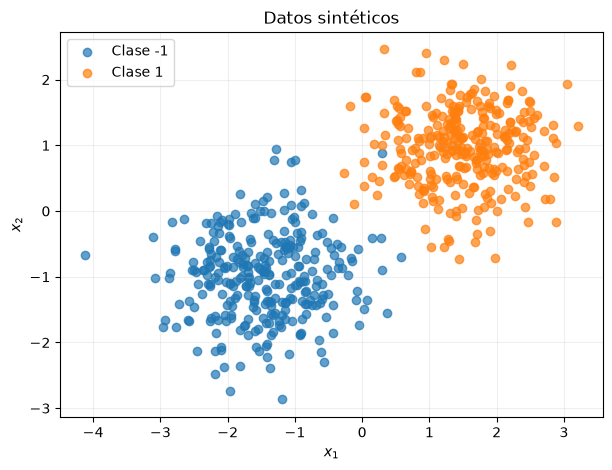

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))

for etiqueta in (-1, 1):
    grupo = datos[datos["y"] == etiqueta]  #filtramos solo las filas de esa clase
    ax.scatter(
        grupo["x1"],
        grupo["x2"],
        alpha=0.7,
        label=f"Clase {etiqueta}",
    )

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Datos sintéticos")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

### Lectura previa

1. ¿parece razonable una frontera lineal?;
2. ¿hay solapamiento?;
3. ¿esta gráfica demuestra separabilidad lineal?;
4. ¿por qué sigue siendo útil observarla?

**Respuesta:**

> 1. Sí, parece razonable. Las dos nubes están centradas en puntos bastante alejados entre sí, así que a simple vista una recta debería poder separar la mayoría de los puntos de cada clase.
> 2. Sí hay algo de solapamiento, más que en los datos del perceptrón. Aquí la desviación estándar es más grande, entonces en los bordes de las dos nubes se meten un poco uno en el territorio del otro. Van a quedar algunos puntos cerca de la frontera, o incluso del lado "equivocado".
> 3. Que se vean separadas en el gráfico es una impresión visual, no una prueba. Podríamos estar viendo mal la escala, o el solapamiento podría ser peor de lo que parece a simple vista. Demostrar separabilidad lineal de verdad significaría encontrar explícitamente los pesos que separan las clases sin error, no solo verlo en el gráfico.
> 4. Porque da una intuición rápida de qué esperar antes de entrenar. Si vieramos las nubes completamente revueltas ya se sabría de entrada que ADALINE no va a poder separar bien esto, sin importar cuánto entrene. Como acá sí se ven medio separadas (aunque con solapamiento), es razonable esperar una exactitud alta pero probablemente no perfecta, lo cual sirve luego para comparar contra lo que realmente obtenga el modelo.

# 5. Train, validation y test

Los pesos deben aprenderse únicamente a partir de `train`.

In [6]:
# partimos X,y en train, val y test usando las proporciones por defecto (70, 15, 15)
(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
) = particion_estratificada(X, y)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (420, 2) (420,)
Validation: (90, 2) (90,)
Test: (90, 2) (90,)


# 6. Una pieza ya implementada: actualización de pesos

La siguiente función se entrega resuelta.

Con:

\[
\mathbf a=\tilde X\mathbf w,
\qquad
\mathbf e=\mathbf y-\mathbf a,
\]

implementa:

\[
\boxed{
\mathbf w_{\text{nuevo}}
=
\mathbf w+
\frac{\eta}{n}
\tilde X^\top\mathbf e
}
\]

Es una actualización **batch**: usa todo el conjunto recibido para producir una actualización global.

Estudie la función. **No la modifique.**

In [7]:
def actualizar_pesos_adaline(
    X_aug: np.ndarray,
    y: np.ndarray,
    w: np.ndarray,
    eta: float,
) -> np.ndarray:
    """Actualiza los pesos de ADALINE mediante batch gradient descent."""
    # X_aug debe ser bidimensional (n_observaciones, n_pesos)
    if X_aug.ndim != 2:
        raise ValueError("X_aug debe ser una matriz bidimensional.")
    # y debe ser unidimensional
    if y.ndim != 1:
        raise ValueError("y debe ser un vector unidimensional.")
    # w debe ser unidimensional
    if w.ndim != 1:
        raise ValueError("w debe ser un vector unidimensional.")
    # X_aug e y deben describir el mismo número de observaciones
    if X_aug.shape[0] != y.shape[0]:
        raise ValueError("X_aug e y deben tener el mismo número de observaciones.")
    # el número de columnas de X_aug (features + sesgo) debe coincidir con len(w)
    if X_aug.shape[1] != w.shape[0]:
        raise ValueError("El número de columnas de X_aug debe coincidir con len(w).")
    # Ninguno de los tres puede tener NaN/infinitos
    if not np.isfinite(X_aug).all():
        raise ValueError("X_aug contiene valores no finitos.")
    if not np.isfinite(y).all():
        raise ValueError("y contiene valores no finitos.")
    if not np.isfinite(w).all():
        raise ValueError("w contiene valores no finitos.")
    # eta debe ser estrictamente positiva
    if eta <= 0:
        raise ValueError("eta debe ser estrictamente positiva.")

    # a = X_aug @ w: salida lineal de todas las observaciones a la vez (vectorizado)
    salida = X_aug @ w
    # y - a: error continuo por observación (no un booleano)
    error = y - salida
    
    # usa el conjunto completo en una sola actualización, no observación por observación
    w_nuevo = w + eta * (X_aug.T @ error) / len(y)

    return w_nuevo

## 6.1 Compruebe una actualización a mano

Considere:

\[
\tilde X=
\begin{bmatrix}
1&0&0\\
1&1&1
\end{bmatrix},
\quad
\mathbf y=
\begin{bmatrix}
-1\\
1
\end{bmatrix},
\quad
\mathbf w=
\begin{bmatrix}
0\\0\\0
\end{bmatrix},
\quad
\eta=0.1.
\]

Calcule manualmente:

1. \(\tilde X\mathbf w\);
2. \(\mathbf e\);
3. \(\tilde X^\top\mathbf e\);
4. \(\mathbf w_{\text{nuevo}}\).

**Resultado esperado por usted:**

\[
\mathbf w_{\text{nuevo}}
=
\boxed{\qquad\qquad\qquad}
\]

In [8]:
# COMPROBACIÓN — NO MODIFICAR

# prueba con números pequeños para poder verificar a mano
X_manual = np.array(
    [
        [1.0, 0.0, 0.0],  # observación 1
        [1.0, 1.0, 1.0],  # observación 2
    ]
)
y_manual = np.array([-1.0, 1.0])  # etiquetas verdaderas
w_manual = np.zeros(3)             # pesos iniciales, todos en cero

# aplicamos la función ya dada sobre este caso pequeño
w_actualizado = actualizar_pesos_adaline(
    X_manual,
    y_manual,
    w_manual,
    eta=0.1,
)

print("Pesos obtenidos:", w_actualizado)
# verificamos que coincide con el cálculo hecho a mano en la celda de markdown anterior:
# a = X_manual @ w_manual = [0, 0]  (pesos en cero, salida en cero)
# e = y_manual - a = [-1, 1]
# X_manual.T @ e = [-1+1, 0+1, 0+1] = [0, 1, 1]
# w_nuevo = [0,0,0] + 0.1 * [0,1,1] / 2 = [0, 0.05, 0.05]
assert np.allclose(w_actualizado, np.array([0.0, 0.05, 0.05]))
print("✓ La función proporcionada reproduce el cálculo esperado.")

Pesos obtenidos: [0.   0.05 0.05]
✓ La función proporcionada reproduce el cálculo esperado.


# 7. Diseñe antes de programar

## No empiece por el código

La función anterior resuelve una operación, no el algoritmo completo.

Piense en necesidades como:

- validar datos e hiperparámetros;
- incorporar \(x_0=1\);
- inicializar pesos;
- calcular salida lineal;
- calcular pérdida;
- coordinar épocas;
- guardar historial;
- convertir salida lineal en una clase;
- predecir sobre nuevas observaciones.

**No significa que cada elemento deba convertirse en una función.** La descomposición es parte del ejercicio.

Complete esta tabla:

| Función propuesta | Responsabilidad | Entradas | Salida | Dependencias |
|---|---|---|---|---|
| `validar_datos_adaline` | Verificar que `X` e `y` cumplen el contrato (dimensiones, valores finitos, etiquetas en {-1,+1}) | `X`, `y` | `True` o devuelve `ValueError` | ninguna |
| `agregar_sesgo` | Incorporar la columna constante $x_0=1$ | `X` | `X_aug` | ninguna |
| `inicializar_pesos` | Inicializar el vector de pesos en cero | `n_caracteristicas` | `w` | ninguna |
| `calcular_salida_lineal` | Calcular $\mathbf a=\tilde X\mathbf w$ para todas las observaciones al mismo tiempo | `X_aug`, `w` | `a` (vector) | ninguna |
| `calcular_perdida` | Calcular $L(\mathbf w)=\frac{1}{2n}\sum(y_i-a_i)^2$ | `y`, `a` | pérdida (float) | ninguna |
| `entrenar_adaline` | Coordinar validación, inicialización y el ciclo de épocas | `X`, `y`, `eta`, `max_epocas` | `w`, `historial` | todas las anteriores + `actualizar_pesos_adaline` (dada) |
| `predecir_adaline` | Coordinar la inferencia sobre datos nuevos | `X`, `w` | predicciones en {-1,+1} | `agregar_sesgo`, `calcular_salida_lineal` |

### Diagrama

Reemplace las cajas por su propuesta:

```text
datos
  │
  ▼
[validar_datos_adaline + agregar_sesgo + inicializar_pesos]
  │
  ▼
[bucle de épocas:
   actualizar_pesos_adaline → calcular_salida_lineal → calcular_perdida]
  │
  ├──────────────► historial
  │
  ▼
pesos entrenados
```

### Justificación

¿Por qué separó las responsabilidades de esa manera?

> Separé las funciones elementales (`agregar_sesgo`, `inicializar_pesos`, `calcular_salida_lineal`, `calcular_perdida`) siguiendo el mismo criterio que habiamos usado en el perceptron: cada una hace una sola cosa, sin efectos secundarios, y se puede probar de forma aislada. `validar_datos_adaline` queda separada de la coordinación para poder reutilizarla y probarla independientemente, igual que validar_datos en el perceptron. `calcular_salida_lineal` se reutiliza tanto dentro del ciclo de entrenamiento como en `predecir_adaline`, evitando repetir la operación `X_aug @ w` en dos lugares distintos. `calcular_perdida` queda separada del paso de actualización para que el historial registre la pérdida después de actualizar los pesos, sin duplicar la lógica de `actualizar_pesos_adaline `. No convertí la aplicación de signo en una función aparte porque es una sola línea (np.where(a > 0, 1, -1)) usada en un único lugar (`predecir_adaline`);no todo tiene que volverse función.

# 8. Pseudocódigo del comportamiento esperado

Este pseudocódigo **no define nombres de funciones**.

```text
RECIBIR X, y, eta y número de épocas

VALIDAR las entradas

INCORPORAR x0 = 1

INICIALIZAR los pesos

PARA cada época:

    ACTUALIZAR los pesos mediante actualizar_pesos_adaline(...)

    CALCULAR la salida lineal con los pesos ya actualizados

    CALCULAR la pérdida de la época

    GUARDAR:
        - número de época
        - pérdida
        - copia de los pesos

DEVOLVER pesos finales e historial
```

Para inferencia:

```text
RECIBIR X y pesos entrenados

INCORPORAR x0 = 1

CALCULAR salida lineal

SI salida > 0:
    clase = +1
EN OTRO CASO:
    clase = -1

DEVOLVER predicciones
```

La función signo **no interviene en la pérdida usada para entrenar ADALINE**.

<details>
<summary><strong>Pista 3 — historial</strong></summary>

Cada época debe permitir recuperar:

- número de época;
- pérdida;
- una copia de los pesos.

</details>

<details>
<summary><strong>Pista 4 — si la pérdida aumenta</strong></summary>

Revise el signo de la actualización, el valor de \(\eta\), que la pérdida use la salida lineal y la escala de las características.

</details>

<details>
<summary><strong>Pista 5 — sesgo</strong></summary>

Mantenga la convención:

\[
x_0=1,
\qquad
w_0 \text{ actúa como sesgo}.
\]

No introduzca un `b` separado.

</details>

# 9. Implemente su arquitectura

Utilice las siguientes celdas para sus funciones auxiliares.

Se espera:

- `type hints`;
- docstrings;
- `raise ValueError` cuando corresponda;
- responsabilidades claras.

Puede añadir más celdas.

In [9]:
# CELDA DE IMPLEMENTACIÓN 1

def validar_datos_adaline(
    X: np.ndarray,
    y: np.ndarray,
) -> bool:
    """Valida el contrato de entrada de ADALINE.

    Args:
        X: Matriz de características, forma (n, d).
        y: Vector de etiquetas en {-1, +1}, forma (n,).

    Returns:
        True si X e y cumplen el contrato.

    Raises:
        ValueError: Si alguna condición del contrato no se cumple.
    """
    # X debe ser una matriz bidimensional (n_observaciones, n_caracteristicas)
    if X.ndim != 2:
        raise ValueError(f"X debe ser bidimensional, pero tiene ndim={X.ndim}.")

    # y debe ser un vector unidimensional (n_observaciones,)
    if y.ndim != 1:
        raise ValueError(f"y debe ser unidimensional, pero tiene ndim={y.ndim}.")

    # X e y deben describir el mismo número de observaciones
    if X.shape[0] != y.shape[0]:
        raise ValueError(
            f"X tiene {X.shape[0]} observaciones pero y tiene {y.shape[0]}."
        )

    # X no puede contener NaN ni infinitos
    if not np.isfinite(X).all():
        raise ValueError("X contiene valores no finitos (NaN o infinitos).")

    # y solo puede tomar los valores -1 y +1
    etiquetas_presentes = set(np.unique(y))
    if not etiquetas_presentes.issubset({-1, 1}):
        raise ValueError(
            f"y solo puede contener -1 y +1, se encontraron: {etiquetas_presentes}."
        )

    return True


def agregar_sesgo(X: np.ndarray) -> np.ndarray:
    """Agrega la característica constante x0 = 1.

    Args:
        X: Matriz de características, forma (n, d).

    Returns:
        Matriz aumentada, forma (n, d+1), con una primera columna de unos.
    """
    n_observaciones = X.shape[0]
    columna_unos = np.ones((n_observaciones, 1))
    X_aug = np.hstack((columna_unos, X))
    return X_aug


def inicializar_pesos(n_caracteristicas: int) -> np.ndarray:
    """Inicializa en cero el vector de pesos, incluido w0.

    Args:
        n_caracteristicas: Número de características originales (sin contar x0).

    Returns:
        Vector de ceros de longitud n_caracteristicas + 1.
    """
    return np.zeros(n_caracteristicas + 1)

In [10]:
# CELDA DE IMPLEMENTACIÓN 2

def calcular_salida_lineal(
    X_aug: np.ndarray,
    w: np.ndarray,
) -> np.ndarray:
    """Calcula la salida lineal a = X_aug @ w para todas las observaciones.

    Args:
        X_aug: Matriz de características ya aumentada con x0 = 1, forma (n, d+1).
        w: Vector de pesos, forma (d+1,).

    Returns:
        Vector de salidas lineales, forma (n,).

    Raises:
        ValueError: Si las dimensiones de X_aug y w son incompatibles.
    """
    # el número de columnas de X_aug debe coincidir con la longitud de w para que el producto matricial tenga sentido
    if X_aug.shape[1] != w.shape[0]:
        raise ValueError(
            f"X_aug tiene {X_aug.shape[1]} columnas pero w tiene longitud {w.shape[0]}."
        )

    #cada fila de X_aug se multiplica por w y se suma, equivalente a aplicar entrada_neta observación por observación, pero vectorizado
    a = X_aug @ w
    return a


def calcular_perdida(
    y: np.ndarray,
    a: np.ndarray,
) -> float:
    """Calcula la pérdida cuadrática media L(w) = (1/2n) * sum((y - a)^2).

    Args:
        y: Vector de etiquetas verdaderas, forma (n,).
        a: Vector de salidas lineales del modelo, forma (n,).

    Returns:
        Valor escalar de la pérdida.

    Raises:
        ValueError: Si y y a no tienen la misma forma.
    """
    if y.shape != a.shape:
        raise ValueError("y y a deben tener la misma forma.")

    n = y.shape[0]
    # error elemento a elemento: e_i= y_i - a_i
    error = y - a
    # Pérdida: media de los errores al cuadrado, dividida por 2 (factor de conveniencia para que el gradiente quede limpio, como vimos en la derivación de la sección 2.1)
    perdida = float(np.sum(error ** 2) / (2 * n))
    return perdida

# 10. Interfaces de integración

Su arquitectura interna es libre, pero las celdas posteriores necesitan dos puntos de entrada comunes.

## 10.1 `entrenar_adaline`

El historial debe tener exactamente:

```python
{
    "epoca": ...,
    "perdida": ...,
    "w": ...,
}
```

La pérdida registrada debe corresponder a los pesos **después de la actualización de esa época**.

No se requiere `early stopping`: ejecute exactamente `max_epocas` épocas.

In [11]:
def entrenar_adaline(
    X: np.ndarray,
    y: np.ndarray,
    eta: float = 0.05,
    max_epocas: int = 100,
) -> tuple[np.ndarray, list[dict[str, object]]]:
    """Entrena ADALINE mediante batch gradient descent.

    Args:
        X: Matriz de características originales.
        y: Vector de etiquetas en {-1, +1}.
        eta: Tasa de aprendizaje estrictamente positiva.
        max_epocas: Número de épocas.

    Returns:
        Tupla (w, historial). Cada registro contiene
        'epoca', 'perdida' y 'w'.

    Raises:
        ValueError: Si los datos o hiperparámetros incumplen el contrato.
    """
    # 1.validamos el contrato de los datos (lanza ValueError si algo está mal)
    validar_datos_adaline(X, y)

    # 2. validamos los hiperparámetros propios de esta función coordinadora
    if eta <= 0:
        raise ValueError(f"eta debe ser estrictamente positiva, se recibió {eta}.")
    if max_epocas <= 0:
        raise ValueError(f"max_epocas debe ser positivo, se recibió {max_epocas}.")

    # 3. incorporamos x0=1 a las características originales
    X_aug = agregar_sesgo(X)

    # 4. inicializamos los pesos en cero
    w = inicializar_pesos(X.shape[1])

    # 5.acumulamos el historial de entrenamiento, epoca por epoca
    historial = []

    # 6.ejecutamos exactamente max_epocas epocas (no hay early stopping como en el perceptron)
    for epoca in range(1, max_epocas + 1):
        # a) Actualizamos los pesos con la función ya dada (una actualización batch que usa todo el conjunto de entrenamiento de una vez)
        w = actualizar_pesos_adaline(X_aug, y, w, eta)

        # b) calculamos la salida lineal incluyendo los pesos ya actualizados
        a = calcular_salida_lineal(X_aug, w)

        # c) Calculamos la pérdida de esta epoca, correspondiente a los nuevos pesos
        perdida = calcular_perdida(y, a)

        # d) guardamos el registro de la epoca. Copiamos w explícitamente, pues si no lo hiciéramos, todas las entradas del historial apuntarían al mismo objeto y terminarían mostrando el w final en todas.
        historial.append({
            "epoca": epoca,
            "perdida": perdida,
            "w": w.copy(),
        })

    return w, historial

## 10.2 `predecir_adaline`

Durante inferencia:

\[
\hat y=
\begin{cases}
+1,&z>0,\\
-1,&z\le0.
\end{cases}
\]

In [12]:
def predecir_adaline(
    X: np.ndarray,
    w: np.ndarray,
) -> np.ndarray:
    """Obtiene predicciones binarias con un ADALINE entrenado.

    Args:
        X: Matriz de características originales.
        w: Vector de pesos entrenado.

    Returns:
        Vector de predicciones en {-1, +1}.
    """
    # 1. Iincluimos x0=1 
    X_aug = agregar_sesgo(X)

    # 2. Calculamos la salida lineal a = X_aug @ w, reutilizando la misma función que usamos durante el entrenamiento
    a = calcular_salida_lineal(X_aug, w)

    # 3. aplicamos la función signo solo aquí: +1 si a > 0, -1 cuando sea el caso contrario
    predicciones = np.where(a > 0, 1, -1)

    return predicciones

# 11. Diseñe sus propias pruebas

En el perceptrón las pruebas fueron proporcionadas. Aquí debe proponerlas usted.

Incluya **al menos cuatro pruebas** relevantes.

Algunas preguntas que pueden inspirarlas:

- ¿se rechazan dimensiones incompatibles?;
- ¿se rechaza \(\eta\le0\)?;
- ¿la pérdida es cero cuando la salida coincide exactamente con \(y\)?;
- ¿la representación con sesgo tiene la forma esperada?;
- ¿las predicciones pertenecen a \(\{-1,+1\}\)?;
- ¿el historial tiene una entrada por época?;
- ¿los pesos almacenados en distintas épocas son copias independientes?

No tiene que utilizar estas mismas pruebas.

In [13]:
# PRUEBAS DEL ESTUDIANTE
# Escriba al menos cuatro pruebas ejecutables.

# Prueba 1: agregar_sesgo debe sumar exactamente una columna de 1
X_prueba = np.array([[2.0, 3.0], [4.0, 5.0]])
X_aug_prueba = agregar_sesgo(X_prueba)
assert X_aug_prueba.shape == (2, 3)
assert np.allclose(X_aug_prueba[:, 0], 1.0)

# Prueba 2: la pérdida debe ser 0 cuando la salida coincide con y
y_prueba = np.array([-1.0, 1.0, 1.0])
a_prueba = np.array([-1.0, 1.0, 1.0])  # salida igual a la etiqueta real
assert calcular_perdida(y_prueba, a_prueba) == 0.0

# Prueba 3: dimensiones incompatibles entre X e y deben rechazarse
try:
    validar_datos_adaline(X_train, y_train[:-1])
except ValueError:
    pass
else:
    raise AssertionError("Debe rechazarse un número distinto de observaciones en X e y.")

# Prueba 4: eta <= 0 no nos sirve
try:
    entrenar_adaline(X_train, y_train, eta=0.0, max_epocas=10)
except ValueError:
    pass
else:
    raise AssertionError("Debe rechazarse eta <= 0.")

# Prueba 5: las predicciones de predecir_adaline deben estar en {-1, +1}
w_prueba, _ = entrenar_adaline(X_train, y_train, eta=0.05, max_epocas=5)
pred_prueba = predecir_adaline(X_train, w_prueba)
assert set(np.unique(pred_prueba)).issubset({-1, 1})

print("✓ Todas las pruebas del estudiante pasaron.")  #todo bien


✓ Todas las pruebas del estudiante pasaron.


# 12. Utilidades para analizar resultados

Estas funciones se entregan implementadas y no pertenecen al núcleo de ADALINE.

In [14]:
def exactitud(
    y_real: np.ndarray,
    y_pred: np.ndarray,
) -> float:
    # los vectores deben tener la misma forma para compararlos elemento a elemento
    if y_real.shape != y_pred.shape:
        raise ValueError("y_real e y_pred deben tener la misma forma.")
    # y_real == y_pred da un array de booleanos 
    # np.mean sobre booleanos da la proporción de aciertos
    return float(np.mean(y_real == y_pred))


def historial_a_dataframe(
    historial: list[dict[str, object]],
) -> pd.DataFrame:
    filas = []  # acumulamos una fila por cada época

    for registro in historial:
        # empezamos la fila con los datos escalares de la época
        fila = {
            "epoca": registro["epoca"],
            "perdida": registro["perdida"],
        }

        # El vector w tiene varias componentes (w0, w1, w2); las desenrollamos en columnas separadas w0, w1, w2... 
        for j, valor in enumerate(registro["w"]):
            fila[f"w{j}"] = valor

        filas.append(fila)

    # ahora cnvertimos la lista de diccionarios en una tabla, una fila por época
    return pd.DataFrame(filas)


def graficar_perdida(
    historial: list[dict[str, object]],
    titulo: str = "Pérdida por época",
) -> None:
    # volvemos a usar la función anterior para tener los datos en formato tabular
    tabla = historial_a_dataframe(historial)

    fig, ax = plt.subplots(figsize=(7, 4))
    # Eje x: numero de epoca. Eje y: valor de la pérdida en esa epoca.
    ax.plot(tabla["epoca"], tabla["perdida"])
    ax.set_xlabel("Época")
    ax.set_ylabel("Pérdida")
    ax.set_title(titulo)
    ax.grid(alpha=0.2)  
    plt.show()


def graficar_frontera(
    X: np.ndarray,
    y: np.ndarray,
    w: np.ndarray,
    titulo: str,
) -> None:
    # esta función solo dibuja en 2D
    if X.ndim != 2 or X.shape[1] != 2:
        raise ValueError("La gráfica requiere exactamente dos características.")

    fig, ax = plt.subplots(figsize=(7, 5))

    # Dibujamos cada clase por separado
    for etiqueta in (-1, 1):
        mascara = y == etiqueta  # True en las filas que pertenecen a esta clase
        ax.scatter(
            X[mascara, 0],
            X[mascara, 1],
            alpha=0.7,
            label=f"Clase {etiqueta}",
        )

    # Rango horizontal para dibujar la recta
    x_min = X[:, 0].min() - 0.5
    x_max = X[:, 0].max() + 0.5

    # La frontera de decisión es w0 + w1*x1 + w2*x2 = 0.
    if np.isclose(w[2],0.0):
        if not np.isclose(w[1], 0.0):
            ax.axvline(-w[0] / w[1], linestyle="--", label="Frontera")
    else:
        # Caso general: despejamos x2 en función de x1 y graficamos la recta
        xs = np.linspace(x_min, x_max, 200)
        ys = -(w[0] + w[1] * xs) / w[2]
        ax.plot(xs, ys, linestyle="--", label="Frontera")

    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title(titulo)
    ax.legend()
    ax.grid(alpha=0.2)
    plt.show()

# 13. Primera prueba de integración

No modifique esta celda para hacerla pasar. Si falla, diagnostique si el problema está en contratos, arquitectura, matemática o integración.

In [15]:
# PRUEBA DE INTEGRACIÓN — NO MODIFICAR

# Entrenamos las 100 epocas con el conjunto de train
w_base, historial_base = entrenar_adaline(
    X_train,
    y_train,
    eta=0.05,
    max_epocas=100,
)

# w_base debe ser un array np con un peso por característica + 1 
assert isinstance(w_base, np.ndarray)
assert w_base.shape == (X_train.shape[1] + 1,)
# Los pesos no deben haberse disparado a inf/NaN durante el entrenamiento
assert np.isfinite(w_base).all()

# El historial debe ser una lista de entrada por época
assert isinstance(historial_base, list)
assert len(historial_base) == 100

# registramos el historial
for registro in historial_base:
    assert set(registro.keys()) == {"epoca", "perdida", "w"}
    assert np.isfinite(registro["perdida"])
    assert registro["perdida"] >= 0
    assert isinstance(registro["w"], np.ndarray)

# probamos también la interfaz de inferencia con los pesos ya entrenados
pred_train_base = predecir_adaline(X_train, w_base)

assert isinstance(pred_train_base, np.ndarray)
assert pred_train_base.shape == y_train.shape
# las predicciones deben estar dentro del conjunto válido {-1, +1}
assert set(np.unique(pred_train_base)).issubset({-1, 1})

print("✓ Las interfaces públicas superan la prueba estructural.")   #todo bien

✓ Las interfaces públicas superan la prueba estructural.


# 14. ¿Qué hace el learning rate?

Entrene con:

\[
\eta\in\{0.001,\;0.01,\;0.05\}.
\]

Compare pérdida inicial, velocidad de descenso, pérdida final y estabilidad.

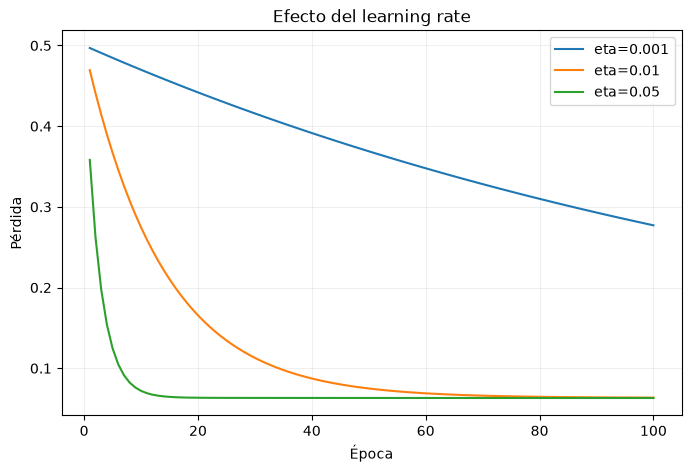

In [16]:
etas = [0.001, 0.01, 0.05]
resultados_eta = {}

for eta in etas:
    w_eta, hist_eta = entrenar_adaline(
        X_train,
        y_train,
        eta=eta,
        max_epocas=100,
    )
    resultados_eta[eta] = {
        "w": w_eta,
        "historial": hist_eta,
    }

fig, ax = plt.subplots(figsize=(8, 5))

for eta, resultado in resultados_eta.items():
    tabla_eta = historial_a_dataframe(resultado["historial"])
    ax.plot(
        tabla_eta["epoca"],
        tabla_eta["perdida"],
        label=f"eta={eta}",
    )

ax.set_xlabel("Época")
ax.set_ylabel("Pérdida")
ax.set_title("Efecto del learning rate")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

### Analice

1. ¿qué valor produce el descenso más lento?;
2. ¿cuál alcanza una pérdida baja más rápidamente?;
3. ¿observa inestabilidad?;
4. ¿qué papel cumple \(\eta\)?

**Respuesta:**

> 1. El que va más lento es eta=0.001 (línea azul), por mucho. Después de las 100 épocas ni siquiera terminó de bajar y va casi en línea recta desde 0.5 hasta como 0.28, y a ese ritmo todavía le faltaría bastante para estabilizarse. Con un paso tan chiquito, cada actualización mueve los pesos muy poco, así que necesita muchísimas más épocas para llegar a algo parecido a la pérdida mínima.
> 2. El que llega más rápido a una pérdida baja es eta=0.05 (verde). Casi se desploma, pues en menos de 10-15 épocas ya está pegado a su valor final y de ahí en adelante se queda plano. eta=0.01 (naranja) también converge, pero le toma bastante más, como hasta la época 70-80 para acercarse a ese mismo nivel.
> 3. No, no veo inestabilidad en ninguna de las tres curvas. Todas bajan de forma suave y monótona, sin rebotes ni picos hacia arriba,ni siquiera la de eta=0.05, que es la más agresiva, muestra oscilación. Si eta fuera demasiado grande sí creería que la pérdida rebota o se dispara, pero acá no pasa eso.
> 4. eta controla qué tan grande es cada paso que dan los pesos hacia donde el gradiente indica que baja la pérdida. Un eta muy chico (0.001) es un paso seguro pero lento, necesita muchas iteraciones para recorrer la misma distancia. Un eta más grande (0.05) da pasos más largos y llega rápido al mínimo, siempre que no se pase de largo y empiece a oscilar. Básicamente es un balance entre velocidad de convergencia y estabilidad del entrenamiento.

# 15. Evaluación sobre train, validation y test

Utilice inicialmente:

\[
\eta=0.05.
\]

Exactitud train:      0.995
Exactitud validation: 0.989
Exactitud test:       1.000


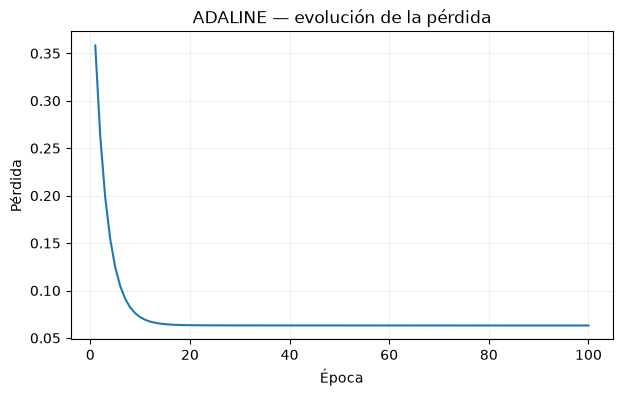

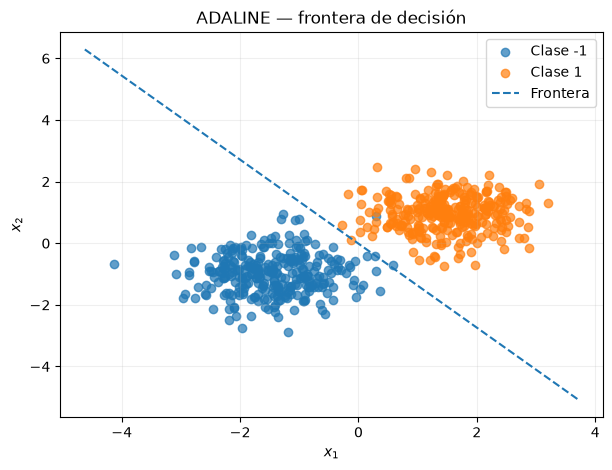

In [17]:
w_final, historial_final = entrenar_adaline(
    X_train,
    y_train,
    eta=0.05,
    max_epocas=100,
)

pred_train = predecir_adaline(X_train, w_final)
pred_val = predecir_adaline(X_val, w_final)
pred_test = predecir_adaline(X_test, w_final)

print(f"Exactitud train:      {exactitud(y_train, pred_train):.3f}")
print(f"Exactitud validation: {exactitud(y_val, pred_val):.3f}")
print(f"Exactitud test:       {exactitud(y_test, pred_test):.3f}")

graficar_perdida(
    historial_final,
    "ADALINE — evolución de la pérdida",
)

graficar_frontera(
    X,
    y,
    w_final,
    "ADALINE — frontera de decisión",
)

### Interprete

1. ¿la pérdida parece converger?;
2. ¿train, validation y test son comparables?;
3. ¿qué relación observa entre pérdida cuadrática y exactitud?;
4. ¿por qué la pérdida puede ser positiva aun con muchas clasificaciones correctas?

**Respuesta:**

> 1. Sí, converge clarísimo. La curva cae fuerte entre la época 0 y la 15, y de ahí en adelante se queda prácticamente plana en ~0.06. Con eta=0.05 esto coincide justo con lo que vi en la comparación de learning rates de la sección 14, pues ese eta era el que llegaba más rápido a estabilizarse, y acá se confirma con las 100 épocas completas.
> 2. Sí, son bastante comparables, 0.995, 0.989 y 1.000, todas por encima del 98%. No hay una caída fuerte de train a validation/test que nos haga sospechar overfitting; si el modelo estuviera memorizando en vez de generalizar, esperaría ver train mucho más alto que los otros dos, y acá no pasa. De hecho test salió el más alto de los tres, lo cual tiene sentido como coincidencia normal en una partición pequeña.
> 3. Van de la mano, pero no son lo mismo. La pérdida baja fuerte y la exactitud sube fuerte al mismo tiempo — tiene sentido, porque a medida que ADALINE ajusta w para que la salida lineal a_i se acerque a y_i, las predicciones (que dependen del signo de esa salida) también se van volviendo más certeras. Pero la pérdida sigue bajando en detalle mucho después de que la exactitud ya llegó a un teacho, porque la pérdida cuadrática es continua y sigue mejorando qué tan cerca está a_i de +-1, aunque el signo ya esté bien.
> 4. Porque la pérdida no mide si until acertó o no, mide qué tan lejos está la salida lineal a_i de la etiqueta exacta y_i que pertenece a {-1,+1}. Puedo clasificar perfecto (signo correcto en el 100% de los casos) y aun así tener a_i=0.85 en vez de 1.0 o a_i=-0.92 en vez de -1. Viéndolo en la gráfica de frontera, los puntos de cada clase no están pegados exactamente sobre la línea de decisión, están dispersos alrededor de sus centros, así que ningún punto tiene a_i exactamente en ±1, siempre va a quedar algo de error residual por chiquito que sea.

# 16. ¿Qué ocurre si las características tienen escalas muy distintas?

Construiremos el mismo problema, pero reemplazaremos:

\[
x_2^\ast=10x_2.
\]

La información de clasificación no cambia, pero la geometría numérica sí.

In [18]:
X_escala = X.copy()
X_escala[:, 1] = 10.0 * X_escala[:, 1]

(
    X_train_e,
    y_train_e,
    X_val_e,
    y_val_e,
    X_test_e,
    y_test_e,
) = particion_estratificada(
    X_escala,
    y,
    semilla=2026,
)

print("Desviaciones de train:")
print(X_train_e.std(axis=0))

Desviaciones de train:
[ 1.6358  11.39046]


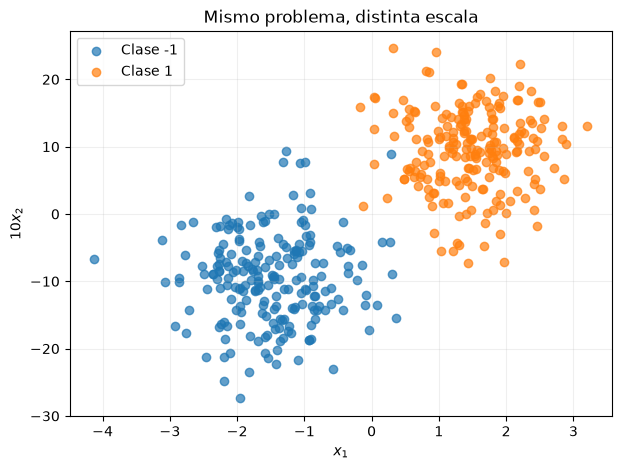

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))

for etiqueta in (-1, 1):
    mascara = y_train_e == etiqueta
    ax.scatter(
        X_train_e[mascara, 0],
        X_train_e[mascara, 1],
        alpha=0.7,
        label=f"Clase {etiqueta}",
    )

ax.set_xlabel("$x_1$")
ax.set_ylabel("$10x_2$")
ax.set_title("Mismo problema, distinta escala")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

## 16.1 Entrene sin estandarizar

Use:

\[
\eta=0.05.
\]

Si la pérdida se comporta mal, no cambie de inmediato el algoritmo. Observe primero.

Primeras pérdidas:


,epoca,perdida
0,1,1.103904e+01
1,2,3.377749e+02
2,3,1.045909e+04
3,4,3.239799e+05
4,5,1.003569e+07


Últimas pérdidas:


,epoca,perdida
45,46,1.360667e+68
46,47,4.214840e+69
47,48,1.305601e+71
48,49,4.044268e+72
49,50,1.252764e+74


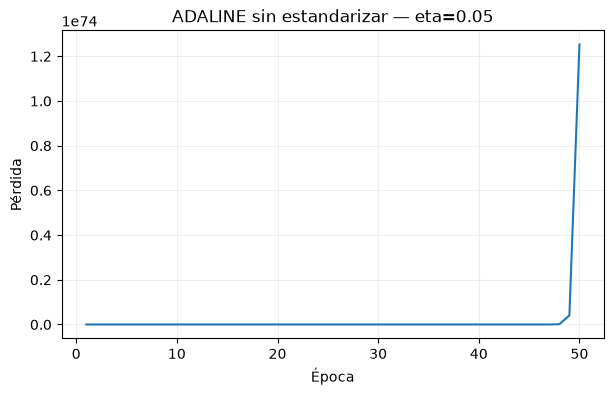

In [20]:
w_escala, hist_escala = entrenar_adaline(
    X_train_e,
    y_train_e,
    eta=0.05,
    max_epocas=50,
)

tabla_escala = historial_a_dataframe(hist_escala)

print("Primeras pérdidas:")
display(tabla_escala[["epoca", "perdida"]].head())

print("Últimas pérdidas:")
display(tabla_escala[["epoca", "perdida"]].tail())

graficar_perdida(
    hist_escala,
    "ADALINE sin estandarizar — eta=0.05",
)

### Observe

Si la pérdida aumenta u oscila:

> ¿qué cambió respecto al experimento anterior si las etiquetas y el problema conceptual son los mismos?

**Respuesta:**

> No cambió el problema en sí — las etiquetas y la separabilidad siguen igual, se ve en el scatter. Lo que cambió fue la escala de x_2(×10), y ahora su desviación es como 7 veces la de x_1 (11.39 vs 1.64). Eso rompe el entrenamiento: la pérdida arranca en 11, para la época 5 ya va en 10^7, y termina en 10^74. Es un crecimiento numérico acelerado, no que el modelo aprenda mal.
>
>La razón es que el mismo eta=0.05 ahora se aplica a un gradiente donde la componente de x_2 es mucho más grande (por su escala), así que el paso sobre w_2 también es mucho más grande. Se pasa de largo del mínimo, el error crece, el siguiente paso es peor todavía;se retroalimenta y se dispara en vez de converger.
>
>Entonces, el mismo eta que funcionaba con variables en escalas parecidas deja de ser una opción segura cuando una domina en magnitud a la otra, porque el tamaño real del paso depende de la escala de los datos, no solo de eta.

# 17. Estandarización

Usaremos únicamente estadísticas de train:

\[
x_j^{\mathrm{std}}
=
\frac{x_j-\mu_j^{(\mathrm{train})}}
{\sigma_j^{(\mathrm{train})}}.
\]

Validation y test se transforman con esos mismos parámetros.

In [21]:
(
    X_train_std,
    X_val_std,
    X_test_std,
    media_train,
    desviacion_train,
) = estandarizar_desde_train(
    X_train_e,
    X_val_e,
    X_test_e,
)

print("Media de train estandarizado:")
print(X_train_std.mean(axis=0))

print("\nDesviación de train estandarizado:")
print(X_train_std.std(axis=0))

Media de train estandarizado:
[-0.  0.]

Desviación de train estandarizado:
[1. 1.]


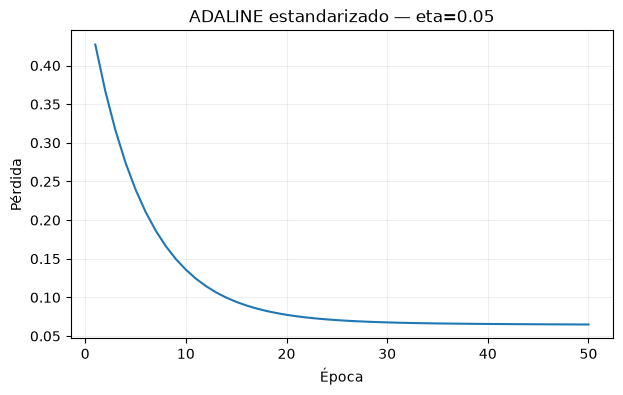

Exactitud train:      0.998
Exactitud validation: 1.000
Exactitud test:       1.000


In [22]:
w_std, hist_std = entrenar_adaline(
    X_train_std,
    y_train_e,
    eta=0.05,
    max_epocas=50,
)

graficar_perdida(
    hist_std,
    "ADALINE estandarizado — eta=0.05",
)

pred_train_std = predecir_adaline(X_train_std, w_std)
pred_val_std = predecir_adaline(X_val_std, w_std)
pred_test_std = predecir_adaline(X_test_std, w_std)

print(f"Exactitud train:      {exactitud(y_train_e, pred_train_std):.3f}")
print(f"Exactitud validation: {exactitud(y_val_e, pred_val_std):.3f}")
print(f"Exactitud test:       {exactitud(y_test_e, pred_test_std):.3f}")

### Compare

1. ¿qué ocurrió sin estandarizar?;
2. ¿qué cambió después?;
3. ¿por qué la escala afecta gradient descent?;
4. ¿qué relación encuentra entre escala, gradiente y learning rate?

**Respuesta:**

> 1. Sin estandarizar, la pérdida explotaba: pasaba de 11 a $10^{74}$ en 50 épocas, puro desborde numérico causado por la escala de $x_2$ siendo 7 veces la de $x_1$.
>
> 2. Después de estandarizar, la pérdida baja suave y converge. Arranca en ~0.43 y se estabiliza cerca de 0.065, con el mismo `eta=0.05` que antes hacía explotar todo. Y la exactitud confirma que el modelo quedó bien: 0.998 en train, 1.000 en validation y test.
>
> 3. Porque gradient descent da pasos proporcionales al gradiente, y el gradiente de cada peso depende de la escala de su variable correspondiente. Si una variable tiene una escala mucho mas grande que otra, su gradiente también es mucho mayor, entonces el mismo `eta` produce un paso gigante en esa dirección y uno chiquito en la otra.
>
> 4. Están directamente relacionados. Al estandarizar, media 0 y desviación 1 en train (justo lo que muestran los números: `[-0. 0.]` y `[1. 1.]`), todas las variables quedan en la misma escala. Eso hace que sus gradientes sean comparables y un solo `eta` sirve para todas por igual, pues ya no depende de qué tan grandes eran los valores originales de cada variable. Por eso estandarizar es un requisito en la práctica cuando se usa gradient descent con variables en escalas distintas.

# 18. Una mirada computacional

Si:

\[
\tilde X\in\mathbb R^{n\times(d+1)},
\]

la actualización contiene:

\[
\tilde X\mathbf w
\quad\text{y}\quad
\tilde X^\top\mathbf e.
\]

Responda:

1. ¿cuál es el costo dominante de una época?;
2. ¿cuál es el costo de \(E\) épocas?;
3. ¿qué costo adicional tiene almacenar una copia de \(\mathbf w\) por época?

**Respuesta:**

> Con $\tilde X \in \mathbb{R}^{n\times(d+1)}$:
>
> 1. El costo dominante de una época son las multiplicaciones matriz-vector $\tilde X\mathbf w$ y $\tilde X^\top\mathbf e$, cada una $O(n(d+1))$; se tocan las $n(d+1)$ entradas de $\tilde X$ una vez. Por época, el costo es $O(nd)$.
>
> 2. El costo de $E$ épocas es $O(E \cdot n \cdot d)$, pues siempre se ejecutan las `max_epocas` completas a diferencia del perceptrón.
>
> 3. Guardar una copia de $\mathbf w$ por época cuesta $O(d+1)$ cada vez que se hace, así que el historial completo cuesta $O(E\cdot(d+1))$. Es económico frente al costo de cómputo ($O(End)$), aunque escalaría si $E$ o $d$ crecieran mucho. En este ejercicio (100 épocas, 2-3 pesos) es casi insignificante.

# 19. Perceptrón vs. ADALINE

Complete:

| Aspecto | Perceptrón | ADALINE |
|---|---|---|
| Entrada neta | $z_i=\mathbf w^\top\tilde{\mathbf x}_i$ | $z_i=\mathbf w^\top\tilde{\mathbf x}_i$ (igual) |
| Etiquetas | $y\in\{-1,+1\}$ | $y\in\{-1,+1\}$ (igual) |
| Salida usada durante aprendizaje | El signo de $z_i$ (bien/mal clasificado) | $z_i$ sin pasar por signo |
| Criterio de cambio de pesos | Solo si $y_iz_i\le0$ (mal clasificado) | Siempre, con base en el error continuo $y_i-z_i$ |
| Función de pérdida explícita | No tiene | Sí, $L(\mathbf w)=\frac{1}{2n}\sum(y_i-a_i)^2$ |
| ¿Usa gradiente? | No | Sí, gradient descent sobre $L$ |
| Actualizaciones por época | Una por observación mal clasificada | Una sola en batch |
| Papel de `sign` | indica si hubo error | Solo al final, para convertir $z$ en clase al predecir |
| Sensibilidad a escala | Baja | Alta. Puede explotar sin estandarizar |


Después responda:

> **¿Por qué ADALINE constituye un puente conceptual entre el perceptrón y las redes neuronales entrenadas mediante gradient descent?**

**Respuesta:**

> Porque en vez de preguntarse si acertó o no, nos preguntamos qué tan lejos está, y usa esa distancia para calcular un gradiente y ajustar los pesos a partir sde él. El perceptrón no generaliza a eso porque su regla es binaria (mal clasificado / bien clasificado), no diferenciable. ADALINE, al minimizar una $L(\mathbf w)$ derivable, ya tiene la misma lógica de entrenamiento que backpropagation, lo único es que no tiene capas ocultas.

# 20. Vuelva a mirar su arquitectura

1. ¿tuvo que modificar su diseño inicial?;
2. ¿qué función terminó teniendo la responsabilidad más compleja?;
3. ¿hay una función con demasiadas responsabilidades?;
4. ¿qué refactorización haría si el proyecto creciera?;
5. ¿dónde ubicó las validaciones y por qué?;
6. ¿qué pieza podría reutilizar en otro modelo entrenado con gradient descent?

**Respuesta:**

> 1. No, el diseño se mantuvo igual al de la tabla de la sección 7. Fue directo porque seguí de cerca el pseudocódigo dado en la sección 8 y no hubo sorpresas a mitad de camino.
>
> 2. `entrenar_adaline`, pues es realmente la única que coordina todo: valida, prepara los datos, corre el bucle de épocas, llama a las demás funciones en el orden correcto y arma el historial.
>
> 3. No la veo sobrecargada, porque aunque coordina varias cosas, cada paso es solo una llamada a otra función (`validar_datos_adaline`, `agregar_sesgo`, `actualizar_pesos_adaline`, etc.); no tiene una logica confusa, sino que orquesta todo.
>
> 4. Si el proyecto creciera, habría que separar la parte de guardar historial en su propia función, para que `entrenar_adaline` quede aún más limpia y ese registro se pueda reutilizar si agrego otra variante de entrenamiento.
>
> 5. Las puse al inicio de cada función elemental (`agregar_sesgo`, `calcular_salida_lineal`, `calcular_perdida`) y una vez más de forma centralizada en `validar_datos_adaline`, llamada al principio de `entrenar_adaline`. Así cada función se protege a sí misma, pero no se repite la misma validación de contrato en cinco lugares distintos.
>
> 6. `calcular_salida_lineal` y `calcular_perdida`, creo que ambas son lo suficientemente genéricas para cualquier modelo lineal entrenado con gradient descent, no tienen nada específico de ADALINE en particular.

# 21. Calidad y entrega

Antes de entregar:

1. reinicie el kernel;
2. ejecute **Run All**;
3. compruebe que no existen errores;
4. verifique que su arquitectura coincide con su implementación;
5. ejecute sus pruebas;
6. interprete las curvas de pérdida;
7. confirme que no modificó `actualizar_pesos_adaline`;
8. no suba el ambiente virtual.

En terminal:

```bash
ruff check .
```

y:

```bash
git status
```

Después:

```bash
git add .
git commit -m "Implementa ADALINE con arquitectura funcional"
git pull
git push
```

## Criterio de finalización

El ejercicio está completo cuando puede defender:

$
\boxed{
\text{formulación matemática}
\rightarrow
\text{arquitectura}
\rightarrow
\text{implementación}
\rightarrow
\text{pruebas}
\rightarrow
\text{optimización}
\rightarrow
\text{evaluación}
}
$